Analyzing result CSVs across different groups to detect any significant trends.

In [1]:
import sys
import csv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import optimal_alpha_csv as opt
from constants import EVALUATED_COSTS_DIR


In [ ]:
fname = EVALUATED_COSTS_DIR + "\pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA1511_ABA_Salt001_M248_10_C_10aba.csv"

homog_opt_info, heterog_opt_info, alpha_diff, sq_orthog_dist_diff = opt.extract_optimal_dist_vals(fname, len(EVALUATED_COSTS_DIR))
print(f"Homogenous Optimal Info: {homog_opt_info} | Heterogeneous Optimal Info: {heterog_opt_info} | Difference in Alpha: {alpha_diff} | Difference in Sq. Ortog. Distance: {sq_orthog_dist_diff}")


In [2]:
def extract_difference_values(arbor_folder):
    folder = Path(arbor_folder)

    alpha_diffs = []
    sq_orthog_dist_diffs = []
    for i, arbor_file in enumerate(folder.glob("*.csv")):
        if i >= 1000: # to prevent errors with encountering an incomplete CSV
            break
        
        homog_opt_info, heterog_opt_info, alpha_diff, sq_orthog_dist_diff = opt.extract_optimal_dist_vals(arbor_file, len(EVALUATED_COSTS_DIR))
        alpha_diffs.append(alpha_diff)
        sq_orthog_dist_diffs.append(sq_orthog_dist_diff)

    return alpha_diffs, sq_orthog_dist_diffs


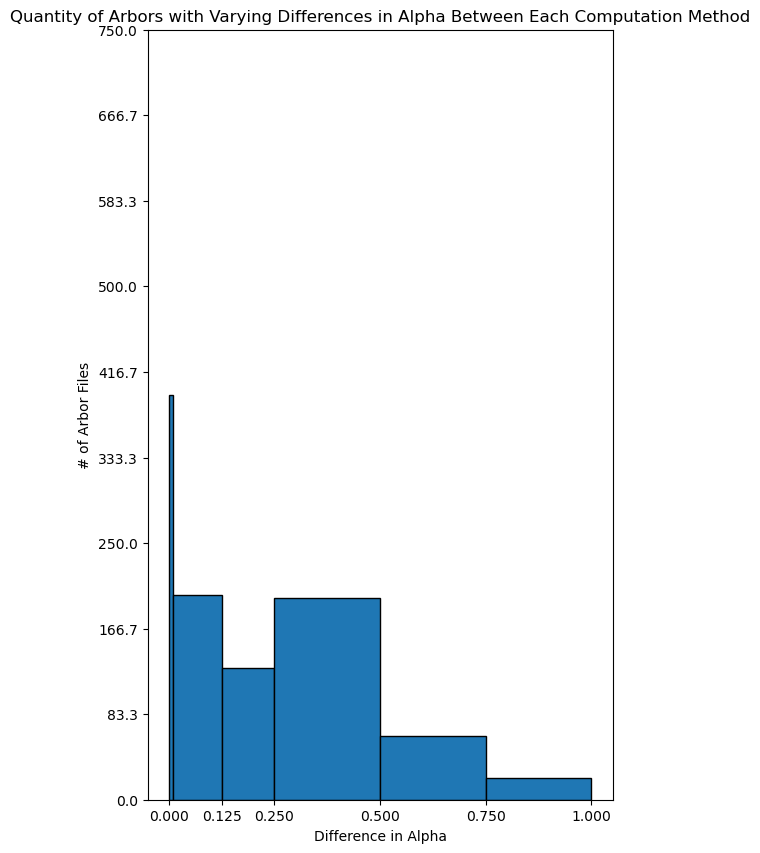

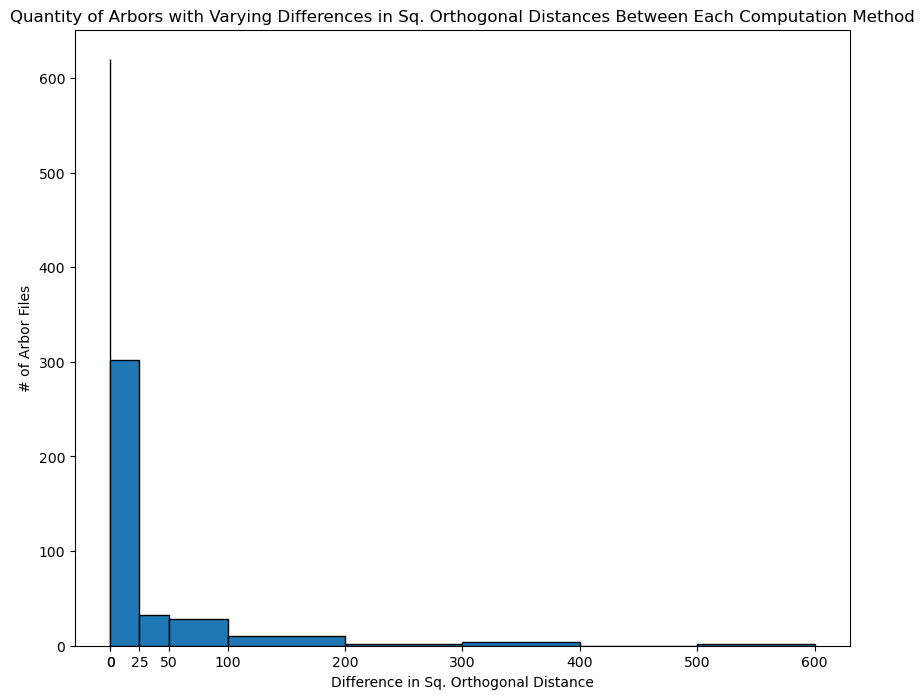

In [3]:
# Creating a histogram that categorizes values based on what range the difference in alpha (between each computation method) falls under

alpha_diffs, sq_orthog_dist_diffs = extract_difference_values(EVALUATED_COSTS_DIR)
plt.figure(figsize=(6, 10))
plt.hist(alpha_diffs, bins=[0, .01, .125, 0.25, 0.5, 0.75, 1.0], edgecolor='black')

plt.yticks(np.linspace(0, 750, 10))
plt.xticks([0, 0.125, 0.25, 0.5, 0.75, 1.0])
plt.xlabel("Difference in Alpha")
plt.ylabel("# of Arbor Files")
plt.title("Quantity of Arbors with Varying Differences in Alpha Between Each Computation Method")
plt.show()

plt.figure(figsize=(10, 8))
plt.hist(sq_orthog_dist_diffs, bins=[0, .01, 25, 50, 100, 200, 300, 400, 500, 600], edgecolor='black')
plt.xticks([0, .01, 25, 50, 100, 200, 300, 400, 500, 600])
plt.xlabel("Difference in Sq. Orthogonal Distance")
plt.ylabel("# of Arbor Files")
plt.title("Quantity of Arbors with Varying Differences in Sq. Orthogonal Distances Between Each Computation Method")
plt.show()

In [73]:
# Looking at data by hormone treatment

df_treatment = pd.read_csv("data/metadata/metadata.csv")
df_results = pd.read_csv("data/results/heterogeneous_results/optimal_distance_values.csv")

df_treatment.columns = df_treatment.columns.str.strip()
df_results.columns = df_results.columns.str.strip()
# print(df_treatment.columns)
# print(df_results.columns)

df_treatment['arbor name'] = df_treatment['arbor name'].str.strip() # removing space in front of the arbor names from metadata.csv

# merging dataframes by arbor
combined_df = df_results.merge(df_treatment, left_on='arbor', right_on='arbor name', how='left')
# print(combined_df.head())
print(combined_df.head(10))

for i in range(100, 200):
    print(combined_df.loc[i, "hormone"])


# filtering df by treatments



                                               arbor     cost method    G  \
0  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...     homogeneous  0.0   
1  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...   heterogeneous  0.0   
2  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...     homogeneous  0.0   
3  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...   heterogeneous  0.0   
4  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...     homogeneous  0.0   
5  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...   heterogeneous  0.0   
6  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...     homogeneous  0.0   
7  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...   heterogeneous  0.0   
8  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...     homogeneous  0.0   
9  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...   heterogeneous  0.0   

   alpha  total squared orthogonal distance experiment  \
0   1.00                           0.914192   PimpiABA   
1   1.00                           0

In [ ]:
no_hormone = []

no_ga = []
lo_ga = []
hi_ga = []

iaa = []
no_iaa = []

_10_aba = []
_1_aba = []
no_aba = []

hi_cyto = []
lo_cyto = []
no_cyto = []

_5_acc = []
no_acc = []
_1_acc = []



In [81]:


def distribution_of_alpha_values(hormone, super_title):
    fig, ax = plt.subplots(1, 3, figsize=(15, 8))
#no_treatment = combined_df[combined_df["hormone"].isin([" noga", " noiaa", " noaba", " nocyto", " noacc"])]

    treatment_all = combined_df[combined_df["hormone"].isin(hormone)]
    #treatment_all = combined_df[combined_df["hormone"] == hormone]
    print(treatment_all)
    treatment_homogeneous = treatment_all[treatment_all["cost method"] == ' homogeneous']
    treatment_heterogeneous = treatment_all[treatment_all["cost method"] == ' heterogeneous']

    ax[0].hist(treatment_all['alpha'], bins=[0, 0.25, 0.5, 0.75, 1.0], color='purple', edgecolor='black')

    ax[0].set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax[0].set_title("Homogeneous and Heterogeneous", fontsize=16)

        # Homogeneous
    ax[1].hist(treatment_homogeneous['alpha'], bins=[0, 0.25, 0.5, 0.75, 1.0], color='blue', edgecolor='black')

    ax[1].set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax[1].set_title("Homogeneous", fontsize=16)

        # Heterogeneous
    ax[2].hist(treatment_heterogeneous['alpha'], bins=[0, 0.25, 0.5, 0.75, 1.0], color='red', edgecolor='black')

    ax[2].set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax[2].set_title("Heterogeneous", fontsize=16)

    fig.supxlabel("Optimal Alpha Values", fontsize=16)
    fig.supylabel("Number of Arbors", fontsize=16)
    fig.suptitle(super_title, fontsize=16)

    plt.show()


                                             arbor     cost method    G  \
648   pimpi_Big1_D3_set1_day3_20190911_100_286_2_S     homogeneous  0.0   
649   pimpi_Big1_D3_set1_day3_20190911_100_286_2_S   heterogeneous  0.0   
650   pimpi_Big1_D3_set1_day3_20190911_104_284_2_S     homogeneous  0.0   
651   pimpi_Big1_D3_set1_day3_20190911_104_284_2_S   heterogeneous  0.0   
652   pimpi_Big1_D3_set1_day3_20190911_120_195_3_C     homogeneous  0.0   
...                                            ...             ...  ...   
2155  pimpi_Big3_D5_set1_day5_20191004_294_249_2_C   heterogeneous  0.0   
2156  pimpi_Big3_D5_set1_day5_20191004_295_227_3_S     homogeneous  0.0   
2157  pimpi_Big3_D5_set1_day5_20191004_295_227_3_S   heterogeneous  0.0   
2158  pimpi_Big3_D5_set1_day5_20191004_296_228_1_S     homogeneous  0.0   
2159  pimpi_Big3_D5_set1_day5_20191004_296_228_1_S   heterogeneous  0.0   

      alpha  total squared orthogonal distance experiment  \
648    0.18                           

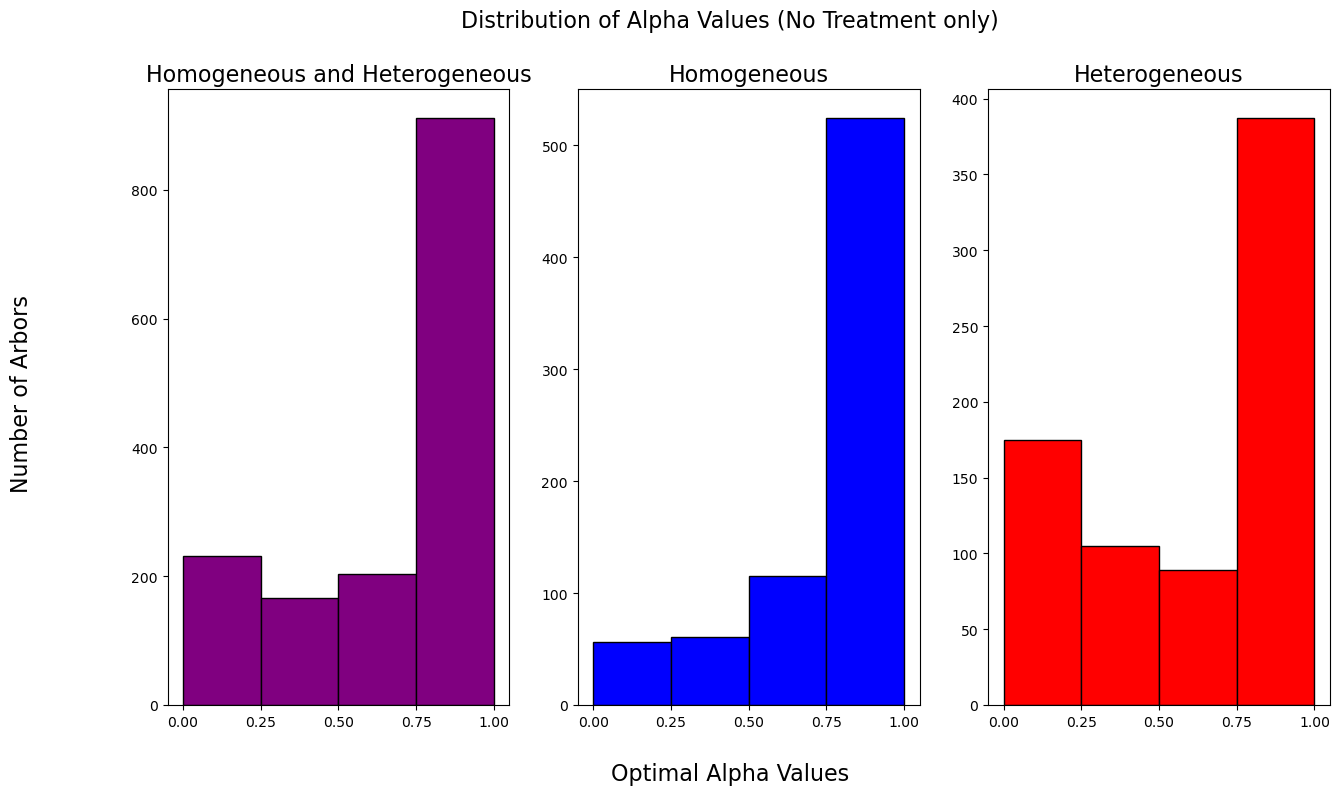

In [82]:
# Distribution of Alpha Values (No Treatment only)
distribution_of_alpha_values([" None"], "Distribution of Alpha Values (No Treatment only)")

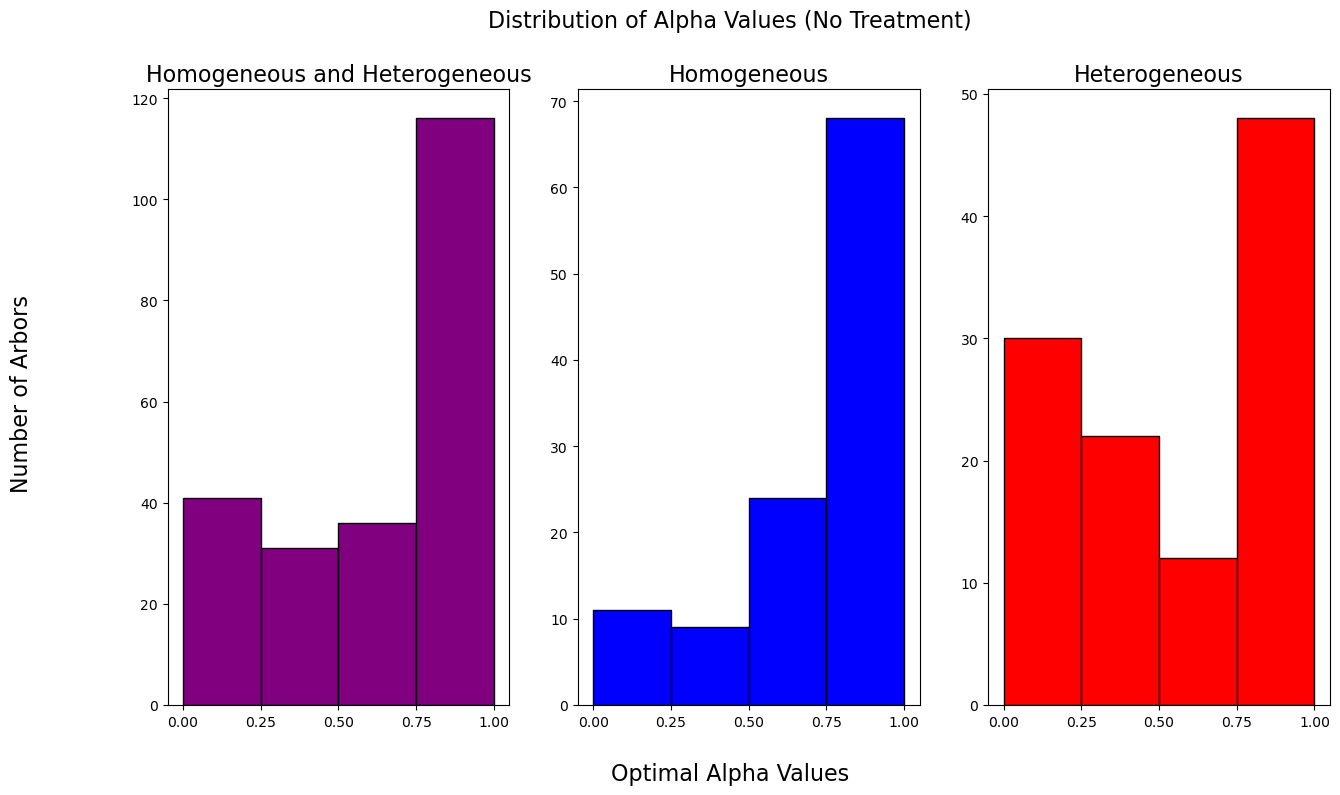

In [ ]:
# Distribution of Alpha Values (No GA, No IAA, No ABA, No Cyto, No Acc) << TODO: Run again since this does not include all files yet (nothing is in the noiaa category)

fig, ax = plt.subplots(1, 3, figsize=(15, 8))
#no_treatment = combined_df[combined_df["hormone"] == ""]

no_treatment = combined_df[combined_df["hormone"].isin([" noga", " noiaa", " noaba", " nocyto", " noacc"])]
no_treatment_homogeneous = no_treatment[no_treatment["cost method"] == ' homogeneous']
no_treatment_heterogeneous = no_treatment[no_treatment["cost method"] == ' heterogeneous']

ax[0].hist(no_treatment['alpha'], bins=[0, 0.25, 0.5, 0.75, 1.0], color='purple', edgecolor='black')

ax[0].set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax[0].set_title("Homogeneous and Heterogeneous", fontsize=16)

    # Homogeneous
ax[1].hist(no_treatment_homogeneous['alpha'], bins=[0, 0.25, 0.5, 0.75, 1.0], color='blue', edgecolor='black')

ax[1].set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax[1].set_title("Homogeneous", fontsize=16)

    # Heterogeneous
ax[2].hist(no_treatment_heterogeneous['alpha'], bins=[0, 0.25, 0.5, 0.75, 1.0], color='red', edgecolor='black')

ax[2].set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax[2].set_title("Heterogeneous", fontsize=16)

fig.supxlabel("Optimal Alpha Values", fontsize=16)
fig.supylabel("Number of Arbors", fontsize=16)
fig.suptitle("Distribution of Alpha Values (No GA, No IAA, No ABA, No Cyto, No Acc)", fontsize=16)

plt.show()


Empty DataFrame
Columns: [arbor, cost method, G, alpha, total squared orthogonal distance, experiment, arbor name, day, Picture #, genotype, replicate, condition, hormone]
Index: []


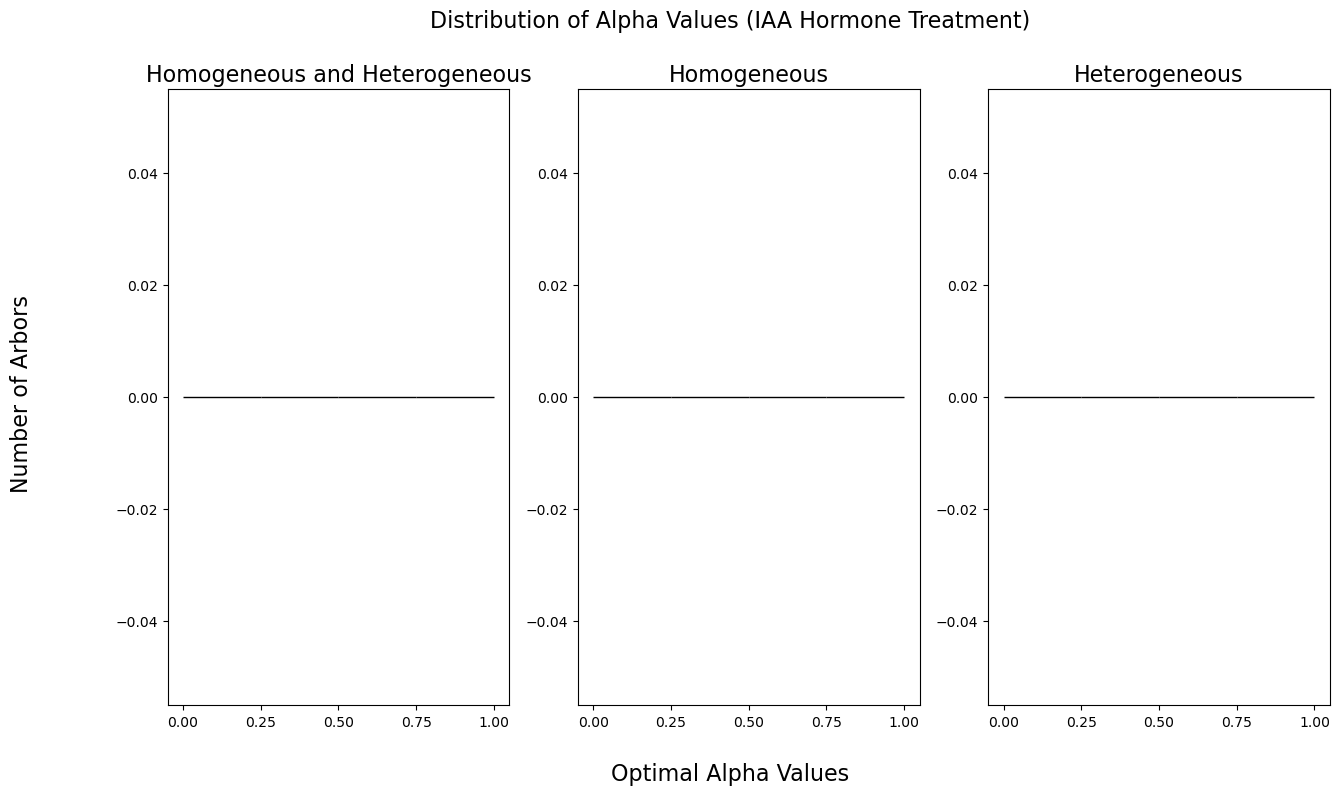

In [ ]:
# Distribution of Alpha Values (IAA Hormone Treatment) << TODO: Run when ALL CSV files calculating homogeneous/heterogenous values have been generated 
distribution_of_alpha_values([" iaa"], "Distribution of Alpha Values (IAA Hormone Treatment)")


Empty DataFrame
Columns: [arbor, cost method, G, alpha, total squared orthogonal distance, experiment, arbor name, day, Picture #, genotype, replicate, condition, hormone]
Index: []


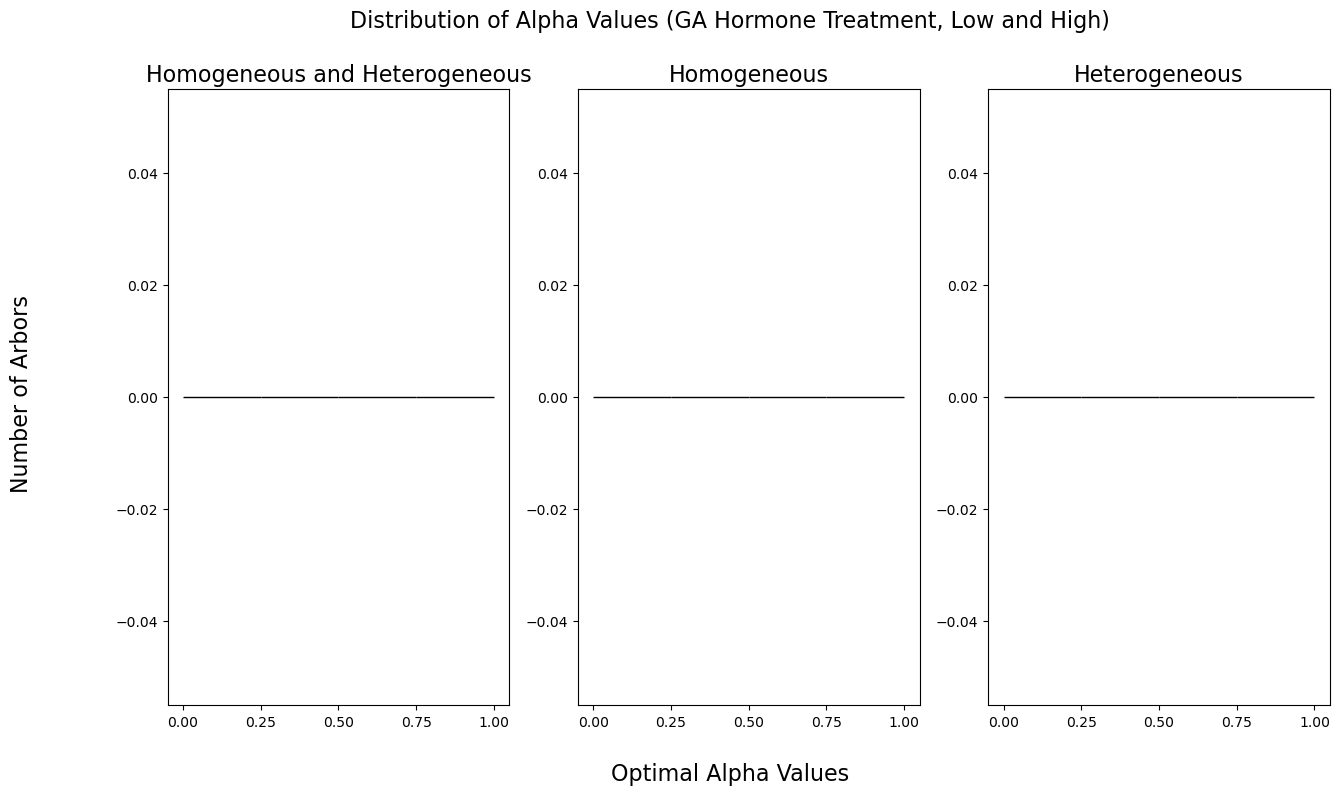

In [ ]:
# Distribution of Alpha Values (GA Hormone Treatment, Low and High) << TODO: Run when ALL CSV files calculating homogeneous/heterogenous values have been generated 
distribution_of_alpha_values([" loga", " higa"], "Distribution of Alpha Values (GA Hormone Treatment, Low and High)")

                                                 arbor     cost method    G  \
0    pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...     homogeneous  0.0   
1    pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...   heterogeneous  0.0   
2    pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...     homogeneous  0.0   
3    pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...   heterogeneous  0.0   
4    pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...     homogeneous  0.0   
..                                                 ...             ...  ...   
289  pimpi_ABA_D9_set1_day9_20220611_RSA_M248M058LA...   heterogeneous  0.0   
290  pimpi_ABA_D9_set1_day9_20220611_RSA_M248M058LA...     homogeneous  0.0   
291  pimpi_ABA_D9_set1_day9_20220611_RSA_M248M058LA...   heterogeneous  0.0   
292  pimpi_ABA_D9_set1_day9_20220611_RSA_M248M058LA...     homogeneous  0.0   
293  pimpi_ABA_D9_set1_day9_20220611_RSA_M248M058LA...   heterogeneous  0.0   

     alpha  total squared orthogonal distance exper

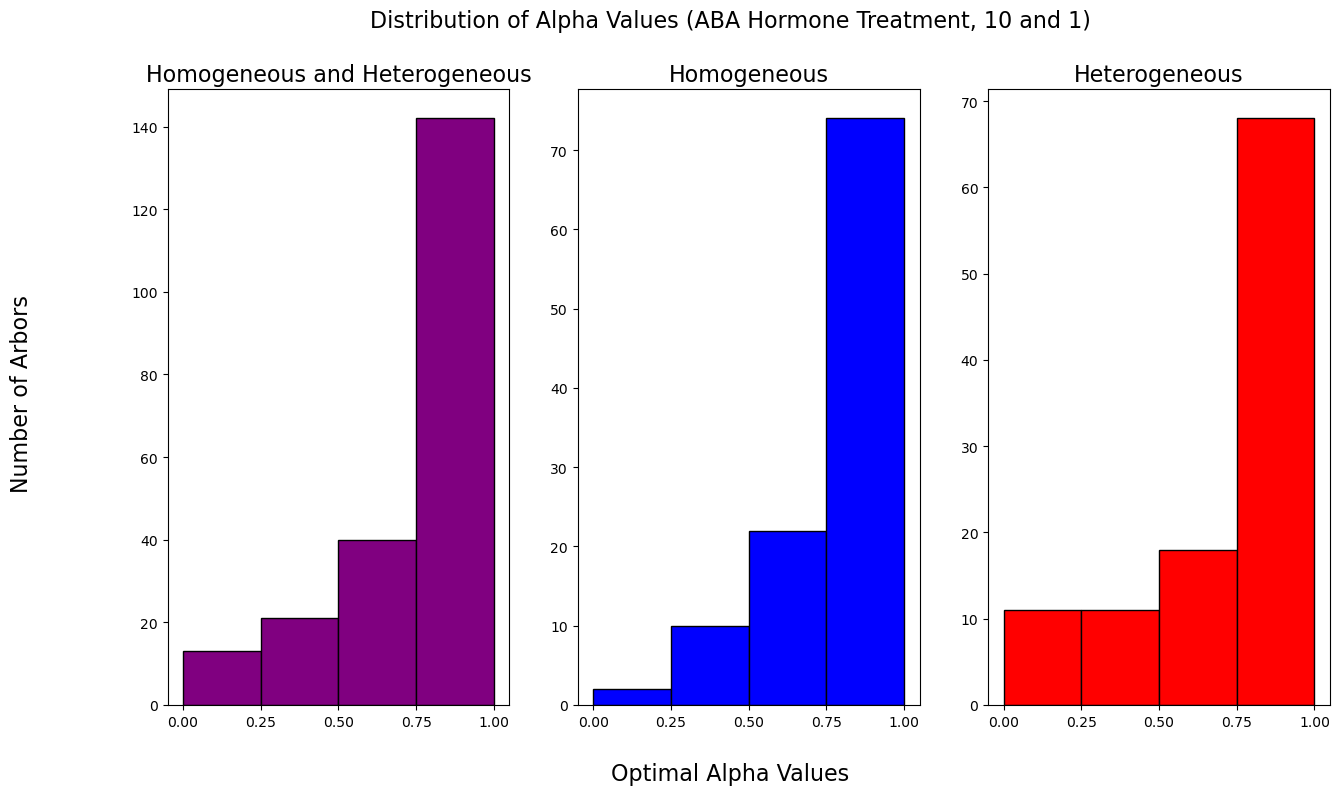

In [85]:
# Distribution of Alpha Values (ABA Hormone Treatment, 10 and 1)
distribution_of_alpha_values([" 10aba", " 1aba"], "Distribution of Alpha Values (ABA Hormone Treatment, 10 and 1)")

Empty DataFrame
Columns: [arbor, cost method, G, alpha, total squared orthogonal distance, experiment, arbor name, day, Picture #, genotype, replicate, condition, hormone]
Index: []


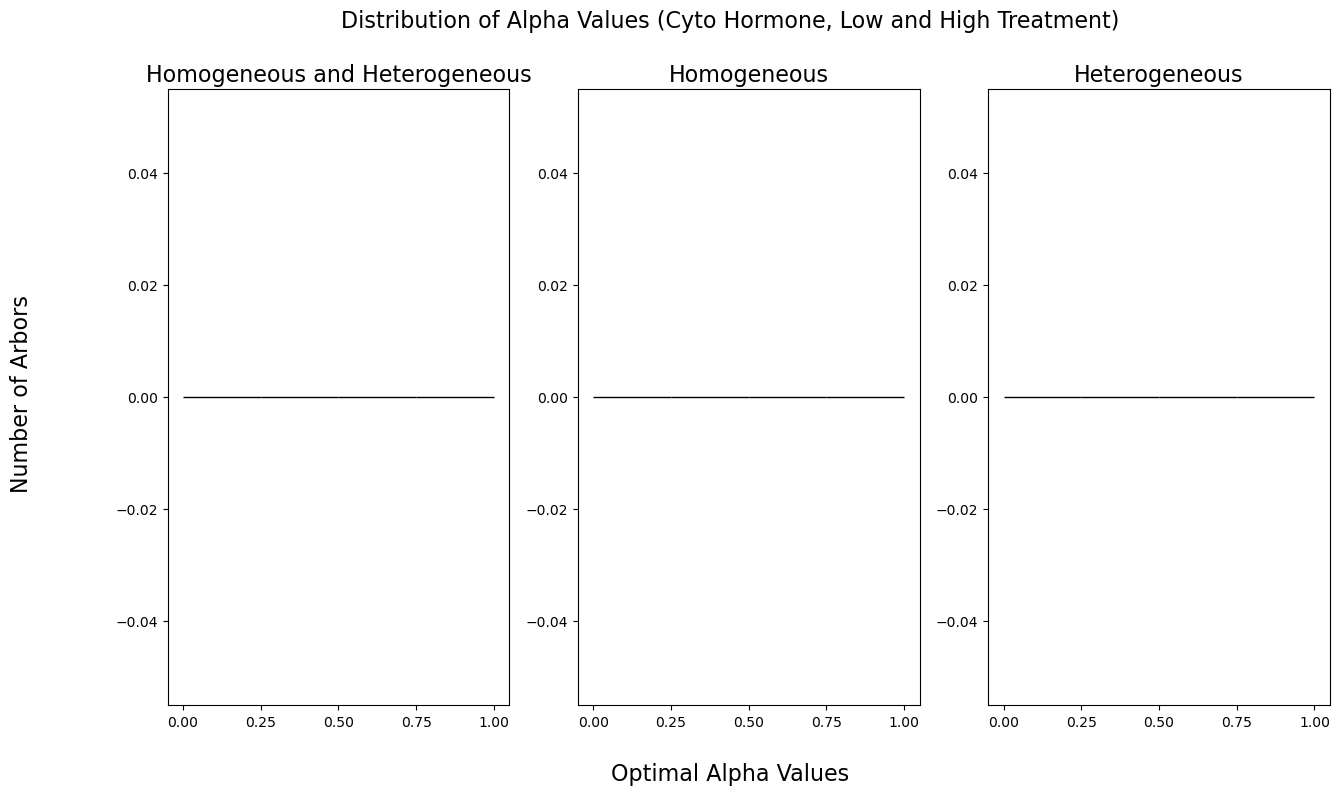

In [86]:
# Distribution of Alpha Values (Cyto Hormone, Low and High Treatment)
distribution_of_alpha_values([" hicyto", " locyto"], "Distribution of Alpha Values (Cyto Hormone, Low and High Treatment)")


                                                 arbor     cost method    G  \
332  pimpi_ACC_D9_set1_day9_20220624_RSA-M248M058LA...     homogeneous  0.0   
333  pimpi_ACC_D9_set1_day9_20220624_RSA-M248M058LA...   heterogeneous  0.0   
334  pimpi_ACC_D9_set1_day9_20220624_RSA-M248M058LA...     homogeneous  0.0   
335  pimpi_ACC_D9_set1_day9_20220624_RSA-M248M058LA...   heterogeneous  0.0   
336  pimpi_ACC_D9_set1_day9_20220624_RSA-M248M058LA...     homogeneous  0.0   
..                                                 ...             ...  ...   
643  pimpi_ACC_D9_set1_day9_20220624_RSA-M248M058LA...   heterogeneous  0.0   
644  pimpi_ACC_D9_set1_day9_20220624_RSA-M248M058LA...     homogeneous  0.0   
645  pimpi_ACC_D9_set1_day9_20220624_RSA-M248M058LA...   heterogeneous  0.0   
646  pimpi_ACC_D9_set1_day9_20220624_RSA-M248M058LA...     homogeneous  0.0   
647  pimpi_ACC_D9_set1_day9_20220624_RSA-M248M058LA...   heterogeneous  0.0   

     alpha  total squared orthogonal distance exper

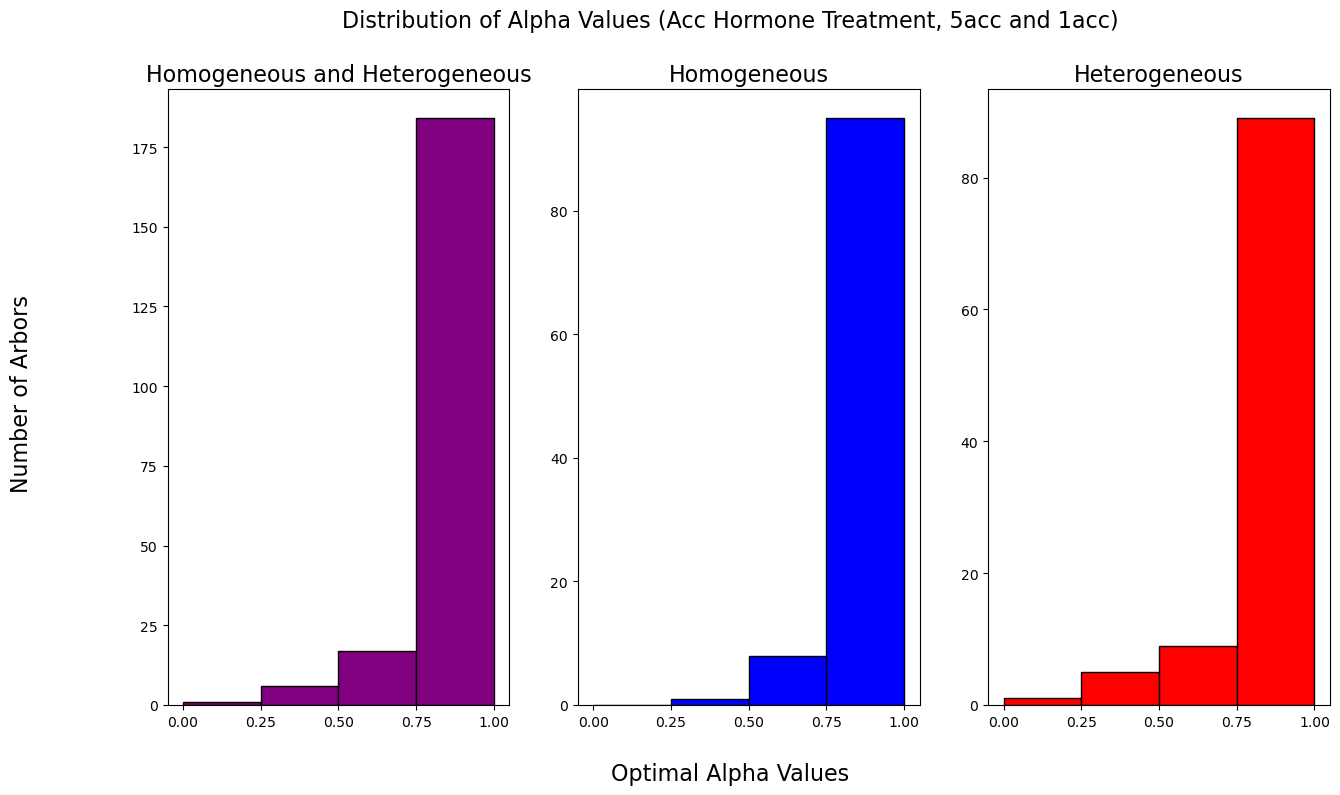

In [87]:
# Distribution of Alpha Values (Acc Hormone Treatment, 5acc and 1acc)
distribution_of_alpha_values([" 5acc", " 1acc"], "Distribution of Alpha Values (Acc Hormone Treatment, 5acc and 1acc)")


In [ ]:
# Looking at data by distribution of total squared orthogonal distance values
